# Does the fear index really collapse the afternoon the Fed speaks? 📉🕑
### The FOMC vol crush — a Wall Street legend that turns out to be **true**, and still unbankable

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Retail_capture%3F: Mixed](https://img.shields.io/badge/Retail_capture%3F-Mixed-8b949e?style=flat-square)

Eight times a year, on a date published **years in advance**, the Federal Reserve announces what it will do with interest rates. At 2:00 pm Eastern the statement hits the wires — and options traders swear the VIX, the market's "fear gauge", **deflates on the spot**: all the insurance bought against a Fed surprise expires worthless the moment the surprise is no longer possible.

That's the claim we test: *uncertainty resolution you can set your watch to.* Most market folklore dies on contact with data. This one **doesn't** — and the interesting part is why you *still* can't get paid for it.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 261 scheduled decision dates (1994→2026) hardcoded from the Fed's own calendar archive — *scheduled* meetings only, because emergency cuts are surprises, the exact opposite of the claim. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fomc_vol_crush import data, strategy as st

FOMC = data.fomc_calendar()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    VIX, SPY, SVXY = data.load_real()
    DF = st.day_frame(VIX, SPY, FOMC)
else:
    VIX = SPY = SVXY = DF = None
print("real cache present:", HAVE_REAL, "| scheduled FOMC decisions:", len(FOMC),
      "| tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1994-01-03', 'end': '2026-06-30', 'n_fomc': 261, 'n_rest': 7916, 'cal_lo': '1994-02-04', 'cal_hi': '2026-06-17', 'fomc_pts': -0.415, 'rest_pts': 0.014, 'gap_pts': -0.429, 'fomc_logpct': -1.97, 'rest_logpct': 0.07, 'welch_pts': -3.51, 'welch_log': -3.94, 'nw_t': -3.47, 'hit': 172, 'hit_pct': 65.9, 'wilson': (60.0, 71.4), 'placebo_p': 5e-05, 'placebo_mean': 0.016, 'placebo_sd': 0.105, 'placebo_draws': 20000, 'event': {-5: (-0.05, -0.53), -4: (-0.079, -0.79), -3: (-0.014, -0.18), -2: (0.301, 2.27), -1: (0.05, 0.35), 0: (-0.415, -3.45), 1: (0.02, 0.1), 2: (-0.105, -1.22), 3: (0.12, 0.82)}, 'runup_pts': 0.209, 'runup_t': 0.9, 'spy_fomc': 1.557, 'spy_rest': 1.296, 'spy_t': 4.04, 'era_early': -0.549, 'era_early_n': 139, 'era_early_t': -4.81, 'era_late': -0.262, 'era_late_n': 122, 'era_late_t': -1.21, 'era_diff_t': 1.15, 'sv_gross': 58.9, 'sv_net5': 48.9, 'sv_net10': 38.9, 'sv_rest': 10.9, 'sv_t': 1.58, 'sv_n': 118, 'sv_hit': 61.9, 'sv_worst': -10.5, 'sv_ann5': 3.91, 'sv_ann10': 3.11, 'sv_post_gross': 14.7, 'sv_post_t': 0.24, 'sv_post_n': 67, 'syn_null_mean': -0.04, 'syn_null_sd': 1.04, 'syn_null_fire': 0, 'syn_planted_t': -15.67, 'fp_vix': 'e876dcb8d22b', 'fp_spy': 'd0ce62443ce7', 'fp_svxy': 'a876bb11537c'}


real cache present: True | scheduled FOMC decisions: 261 | tape days: 8177


## The answer first

| Question | Answer |
|---|---|
| Does the VIX drop on Fed decision days? | **Yes — sharply.** About **-0.4 points (≈ -2%)** on the average decision day, versus roughly zero on a normal day. It fell on **66%** of the 261 decisions since 1994. Odds it's a calendar fluke: about **1 in 20,000**. |
| Is the market actually *calm* that afternoon? | **No — that's the beautiful part.** The S&P's actual intraday swing is *bigger* than average on Fed days. Implied (expected) volatility collapses while realized volatility is loud — the definition of *uncertainty being resolved*, not of a quiet day. |
| Does the drop bounce back tomorrow? | **No.** Day +1 is flat. The fear premium is gone for good — the event is over. |
| Can you trade it? | **Not really.** The VIX itself isn't buyable. The retail short-vol ETF (SVXY) held for just the decision day made **+59 bps per event** on paper — but that's statistically uncertifiable, nearly zero since 2018, and one bad Fed afternoon cost **-10%**. |

> The physics is real. The paycheck is not.

## 1 · The claim

> *"Ahead of every Fed meeting, option prices carry an extra premium for the chance of a shock. At 2 pm on decision day the shock either happens or it doesn't — either way the **uncertainty premium evaporates**, and the VIX crushes into the close."*

It's not just floor talk: academics found that a striking share of all *sudden downward volatility jumps* land on FOMC afternoons (Amengual & Xiu 2018). And unlike most calendar stories, this one has a **mechanism you can state in one sentence**: scheduled uncertainty must leave the option surface the moment it resolves.

## 2 · So what?

If true, this is the cleanest possible demonstration that **implied volatility prices events, not calm** — and it should tempt every retail trader with the same idea: *short volatility into the meeting, collect the crush at 2 pm.* Entire products exist for exactly that trade (SVXY — and its late twin XIV, which died trying in 2018).

So we ask three things: is the crush real, does the day around it behave the way the story says, and can the obvious one-day retail trade actually bank it after costs?

## 3 · How would we even know?

- **The calendar.** All **261** scheduled FOMC decision dates from 1994-02-04 to 2026-06-17, hardcoded from the Fed's calendar archive. The statement lands at 2:00/2:15 pm ET; the VIX closes at 4:15 pm — so the daily close already contains the crush.
- **The comparison.** The VIX's daily change on those 261 days vs the other **7,916** trading days since 1994.
- **The luck check.** Draw 261 random days instead, 20,000 times — how often does a random calendar produce a drop that big?
- **The trade check.** Buy SVXY at the close *before* the decision (the date is public years ahead — no crystal ball needed), sell at the decision-day close, pay costs.

## 4 · The teardown — let's actually look

**First, the headline.** Average daily VIX change on decision days vs every other day.

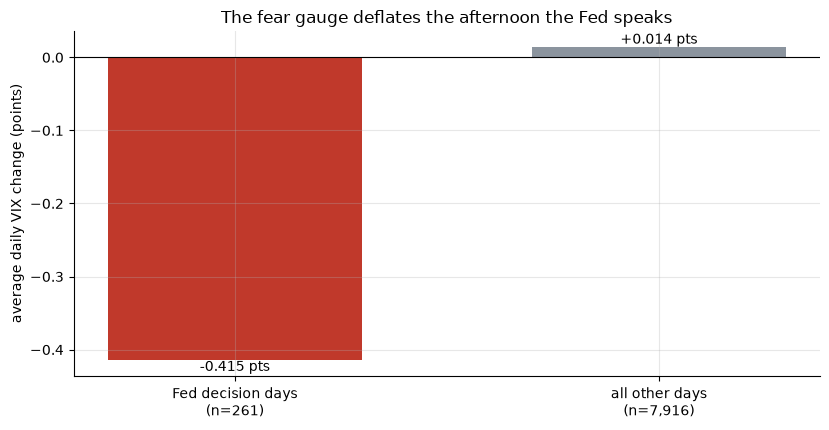

decision days -0.415 pts   other days +0.014 pts


In [2]:
if HAVE_REAL:
    s = st.decision_day_stats(DF)
    fp, rp = s['fomc_pts'], s['rest_pts']
else:
    fp, rp = R['fomc_pts'], R['rest_pts']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['Fed decision days\n(n=261)','all other days\n(n=7,916)'], [fp, rp],
       color=[RED, GREY], width=.6)
for i,v in enumerate([fp, rp]): ax.annotate(f'{v:+.3f} pts',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('average daily VIX change (points)')
ax.set_title('The fear gauge deflates the afternoon the Fed speaks')
plt.tight_layout(); plt.show()
print(f'decision days {fp:+.3f} pts   other days {rp:+.3f} pts')

There it is: **-0.415 points** on the average decision day (about **-2%** of the VIX level) against **+0.014** — i.e. nothing — on a normal day. The VIX fell on **172/261 = 65.9%** of decisions. The quants notebook shows a random calendar beats this about **1 time in 20,000** — this is not luck.

**Next, the anatomy.** What does the whole week around the decision look like?

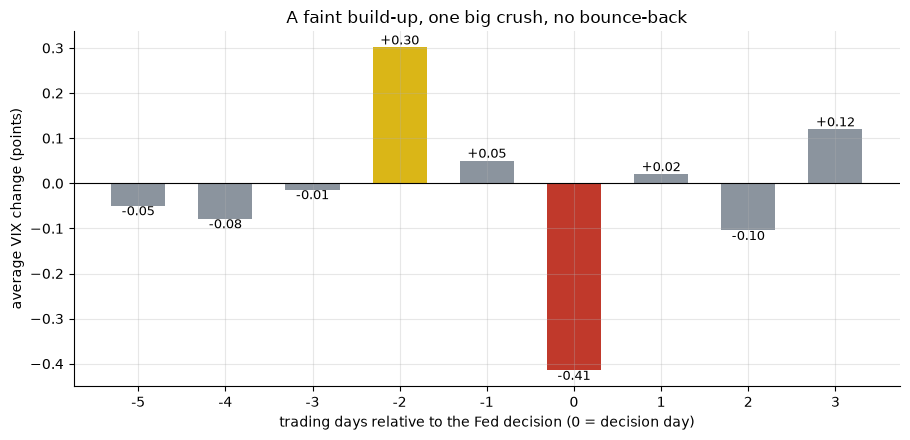

offsets: {-5: -0.05, -4: -0.079, -3: -0.014, -2: 0.301, -1: 0.05, 0: -0.415, 1: 0.02, 2: -0.105, 3: 0.12}


In [3]:
if HAVE_REAL:
    ev = st.event_study(DF, FOMC)
    ks, ms = list(ev.index), list(ev['mean_pts'])
else:
    ks = sorted(R['event']); ms = [R['event'][k][0] for k in ks]
fig, ax = plt.subplots(figsize=(9.2, 4.5))
cols = [RED if k==0 else (AMBER if k==-2 else GREY) for k in ks]
ax.bar([str(k) for k in ks], ms, color=cols, width=.62)
for i,v in enumerate(ms): ax.annotate(f'{v:+.2f}',(i,v),ha='center',
    va='top' if v<0 else 'bottom', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading days relative to the Fed decision (0 = decision day)')
ax.set_ylabel('average VIX change (points)')
ax.set_title('A faint build-up, one big crush, no bounce-back')
plt.tight_layout(); plt.show()
print('offsets:', {k: round(m,3) for k,m in zip(ks, ms)})

Three things to read off this chart:

1. **The build-up is faint.** The five days before the meeting add only about **+0.21 points in total** — statistically indistinguishable from nothing. The "VIX always ramps into the Fed" half of the folklore barely exists.
2. **The crush is the event.** Day 0: **-0.41 points**, by far the largest bar.
3. **It doesn't come back.** Day +1 is **+0.02** — flat. The fear premium isn't *displaced*, it's *extinguished*.

**And here's the elegant bit** — the market isn't calm that day. It's loud:

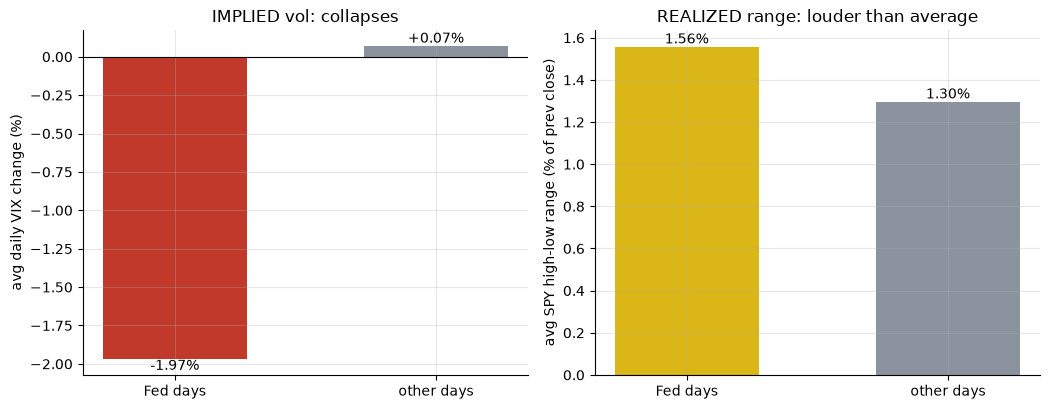

SPY range: Fed days 1.557%  vs other 1.296%


In [4]:
if HAVE_REAL:
    rg = st.spy_range_stats(DF)
    a, b = rg['fomc_range_pct'], rg['rest_range_pct']
else:
    a, b = R['spy_fomc'], R['spy_rest']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar(['Fed days','other days'], [R['fomc_logpct'], R['rest_logpct']], color=[RED, GREY], width=.55)
a1.axhline(0, c='k', lw=.8); a1.set_title('IMPLIED vol: collapses')
a1.set_ylabel('avg daily VIX change (%)')
for i,v in enumerate([R['fomc_logpct'], R['rest_logpct']]):
    a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top' if v<0 else 'bottom')
a2.bar(['Fed days','other days'], [a, b], color=[AMBER, GREY], width=.55)
a2.set_title('REALIZED range: louder than average')
a2.set_ylabel('avg SPY high-low range (% of prev close)')
for i,v in enumerate([a, b]): a2.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'SPY range: Fed days {a:.3f}%  vs other {b:.3f}%')

The S&P swings **1.56%** high-to-low on Fed days vs **1.30%** normally — the decision day is one of the *noisier* days of the calendar. Yet implied volatility drops ~2% into that same close. That combination — *loud day, deflating fear gauge* — is exactly what "uncertainty resolution" looks like, and it's why this isn't some artefact of quiet afternoons.

**Finally, the trade.** Can you actually collect the crush with the retail short-vol ETF, held for just that one day?

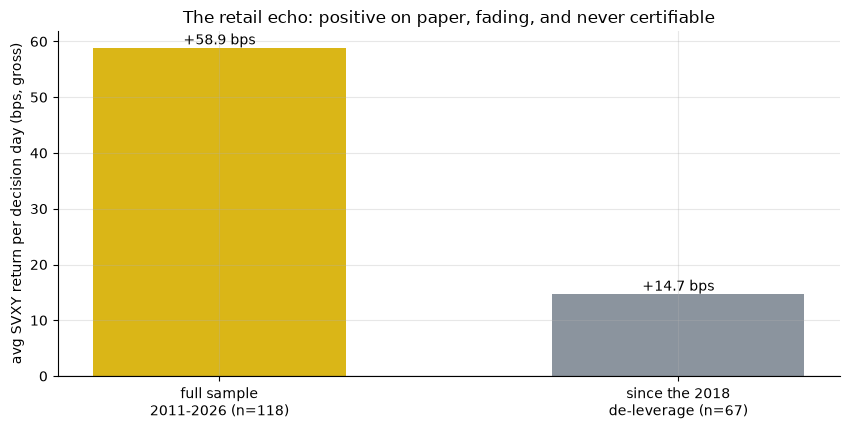

SVXY per decision day: full +58.9 bps  |  post-2018 +14.7 bps


In [5]:
if HAVE_REAL:
    sv = st.svxy_capture(SVXY, FOMC, cost_bps=5.0)
    sv2 = st.svxy_capture(SVXY, FOMC, cost_bps=5.0, start=data.SVXY_DELEV)
    g, g2 = sv['gross_bps'], sv2['gross_bps']
else:
    g, g2 = R['sv_gross'], R['sv_post_gross']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['full sample\n2011-2026 (n=118)','since the 2018\nde-leverage (n=67)'],
       [g, g2], color=[AMBER, GREY], width=.55)
for i,v in enumerate([g, g2]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('avg SVXY return per decision day (bps, gross)')
ax.set_title('The retail echo: positive on paper, fading, and never certifiable')
plt.tight_layout(); plt.show()
print(f'SVXY per decision day: full {g:+.1f} bps  |  post-2018 {g2:+.1f} bps')

On paper: **+59 bps per event** gross, ~**+49 bps** after costs, ≈ **+3.9%/yr** from eight afternoons of "work". But — 

- the statistics **can't certify it** (it's within luck's reach at *t* = 1.58; the bar is 2);
- since SVXY halved its exposure after the 2018 "Volmageddon", the edge is **+15 bps at t = 0.24** — statistically nothing;
- the worst single decision day cost **-10.5%** — one bad afternoon erases a year of edge — and this product's twin (XIV) went to zero in a single day.

Why doesn't the obvious trade work when the crush is so real? Because SVXY doesn't hold the VIX — nobody can. It holds VIX **futures**, and futures traders *also* know the Fed calendar: they price the crush in ahead of time. What's left for you is only the *surprise* part — which is, by definition, a coin flip.

## 5 · The verdict

- **Signal — Real.** The VIX drops **~0.4 points (~2%)** into the decision-day close, fell on **66%** of 261 scheduled decisions since 1994, the drop survives every robustness check we throw at it, and it *sticks*. One of the rare pieces of market folklore that is simply true.
- **Tradability — Mirage.** The index isn't buyable, futures pre-price the event, and the retail echo is thin, uncertifiable, and carries gap-to-zero tail risk.
- **"Retail can bank it with a 1-day SVXY hold"? — Mixed.** Right direction, real positive average in sample — but statistically unprovable, roughly zero since 2018, and one −10.5% afternoon away from a very bad year.

## 6 · Going further 🚪

- **The event premium is the general lesson.** Earnings, CPI mornings, elections — implied vol prices *scheduled events*, and the premium leaves the surface the moment the event resolves. The Fed is just the cleanest, most metronomic case.
- **Where the pros actually play it** is in the *options on the day* (straddles, calendars) and the *futures basis* into the meeting — instruments that isolate the event premium instead of riding a leveraged ETP through it.
- **Sibling studies:** the [pre-FOMC equity drift](../../517-pre-fomc-drift/) (returns *before* the statement), the [FOMC cycle](../../135-fomc-cycle/) (week-parity returns) and the [blackout window](../../322-fomc-blackout/) — none of them is this study: the VIX **on** the day.

*Think you can catch the crush better than SVXY does? Show a net, certifiable edge in the options themselves — after the market-maker's spread on Fed afternoons — then we'll talk.*